In [ ]:
import numpy as np
from MonteCarlo import simular_una_temperatura, graficar_historial, graficar_historial_normalizado, calcular_metricas_finales, calcular_metricas_desde_csv

In [2]:
#np.random.seed(2*np.random.randint(0, 1_000_000)+1) #Semilla aleatoria
np.random.seed(0)
L = 5 #Tamaño de la red
S = np.random.choice([-1, 1], size=(L, L))
S

array([[-1,  1,  1, -1,  1],
       [ 1,  1,  1,  1,  1],
       [ 1, -1, -1,  1, -1],
       [-1, -1, -1, -1,  1],
       [-1,  1,  1, -1, -1]])

In [4]:
mcs_max = 100000
mcs_steps=range(0, mcs_max)
J1 = 1
T = 1

(historial_E, 
historial_M, 
historial_Ms, 
E_prom, 
E2_prom, 
M_prom, 
M2_prom,
Ms_prom, 
Ms2_prom, 
Ms4_prom, 
mcs_steps) = simular_una_temperatura(S, 10000, 1, 1, False)


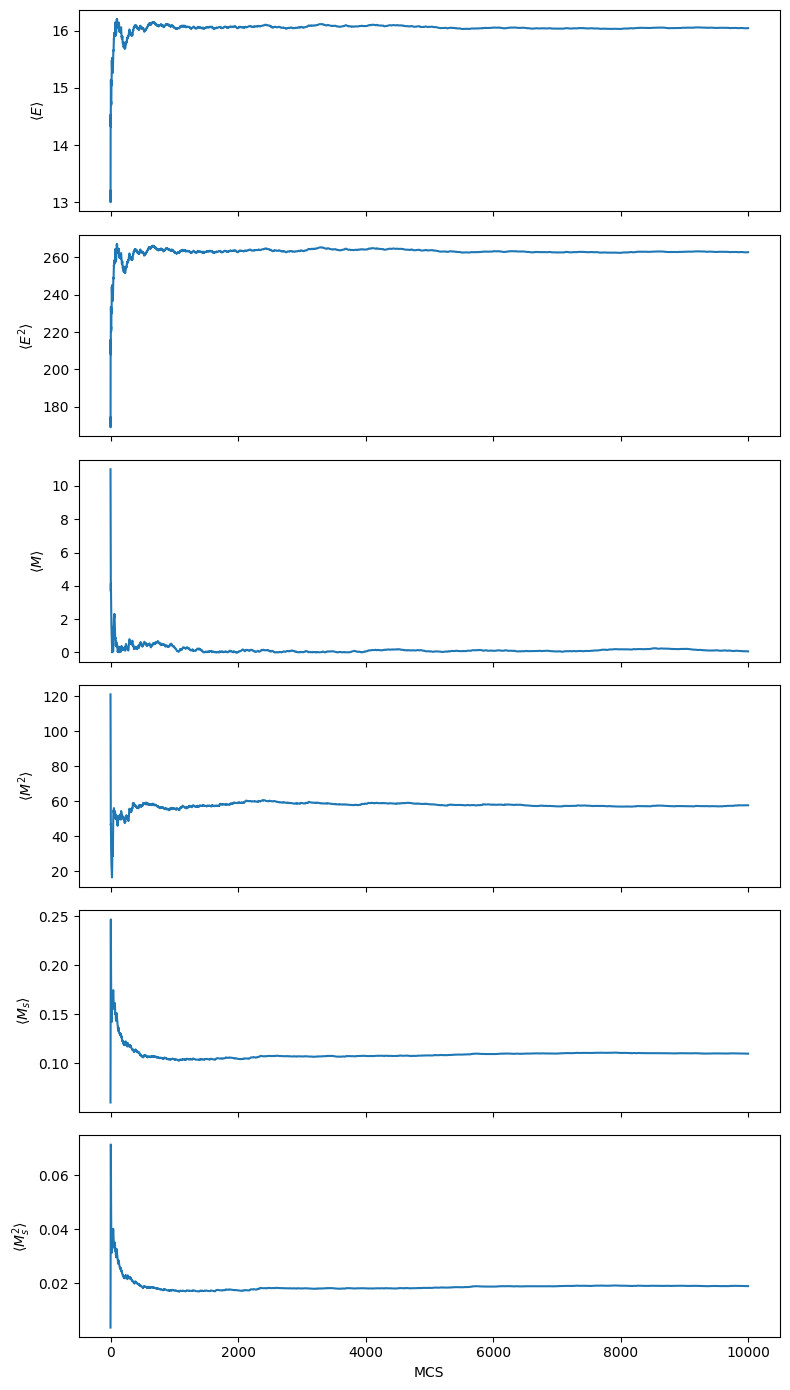

In [5]:
graficar_historial(mcs_steps, E_prom, E2_prom, M_prom, M2_prom, Ms_prom, Ms2_prom)

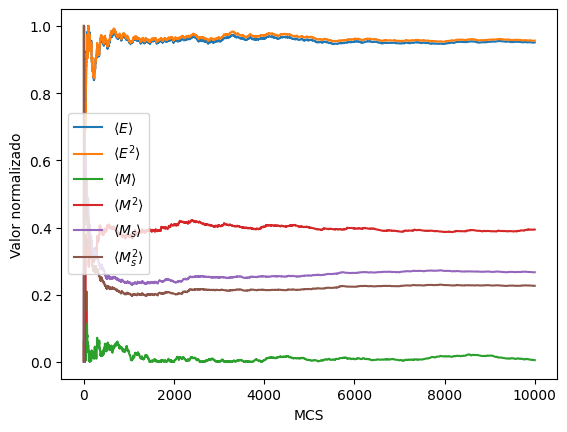

In [6]:
graficar_historial_normalizado(mcs_steps, E_prom, E2_prom, M_prom, M2_prom, Ms_prom, Ms2_prom)

In [7]:
tao = 2000
calcular_metricas_finales(tao, historial_E, historial_Ms, L, T)

{'T': 1,
 'L': 5,
 'E': np.float64(-16.04599999999985),
 'Ms': np.float64(0.11114000000000002),
 'Cv': np.float64(0.20955855999999812),
 'chi_s': np.float64(0.17491751),
 'U': np.float64(-0.009213245490998556)}

In [ ]:
from MonteCarlo import correr_barrido_paralelo

L = [16, 24]
T = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
mcs_max = 10_000
tao = 3000  # deja 7000 MCS de muestreo por intento; revisar si algun (L, T) necesita mas
n_intentos = 100

# 2 (L) x 2 (frontera) x 8 (T) x 100 (intentos) = 3200 corridas independientes,
# repartidas entre los nucleos disponibles. Con L=16/24 y mcs_max=10_000, esto
# deberia tardar del orden de un par de horas.
df_resultados = correr_barrido_paralelo(L_lista=L, T_lista=T, mcs_max=mcs_max, tao=tao, n_intentos=n_intentos)
df_resultados.to_csv("resultados_intentos.csv", index=False)
df_resultados


In [ ]:
import pandas as pd
from MonteCarlo import resumir_intentos, graficar_observable_con_error

df_resultados = pd.read_csv("resultados_intentos.csv")
resumen = resumir_intentos(df_resultados)
resumen.to_csv("resumen_final.csv", index=False)

graficar_observable_con_error(resumen, "Ms", r"$M_s$", titulo="Ms(T) con barras de error (SEM sobre 100 intentos)")
graficar_observable_con_error(resumen, "chi_s", r"$\chi_s$", titulo="chi_s(T) con barras de error (SEM sobre 100 intentos)")
